<a href="https://colab.research.google.com/github/solomon7-data/Athlete/blob/main/HIV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('https://raw.githubusercontent.com/solomon7-data/HIV_DATA1/main/HIV.csv', encoding='latin1')

# Set columns and transpose

df = df.transpose()
df.columns = df.iloc[1]
df = df.iloc[1:].reset_index(drop=True)
df = df.drop(df.index[0]).reset_index(drop=True)
df.head()


Unnamed: 1,Activity,HIV - HIV Testing Service provided,HIV Prevention and Control,Clients receiving HIV test results (at VCT),"< 1 year, Male","< 1 year, Female","1 - 4 years, Male","1 - 4 years, Female","5 - 9 Years, Male","5 - 9 Years, Female",...,Number treated for Hepatitis B,"< 15 Years, Male","< 15 Years, Female",">= 15 Years, Male",">= 15 Years, Female",Number treated for Hepatitis C,"< 15 Years, Male","< 15 Years, Female",">= 15 Years, Male",">= 15 Years, Female"
0,Meskerem 2018,1,NaN,134,NaN,NaN,NaN,NaN,NaN,NaN,...,25,NaN,NaN,11,14,10,NaN,1,7,2
1,Tikemet 2018,1,NaN,100,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Hidar 2018,1,NaN,107,NaN,NaN,NaN,NaN,NaN,NaN,...,2,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
3,Tahesas 2018,1,NaN,144,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Tir 2018,1,NaN,118,NaN,NaN,NaN,NaN,NaN,NaN,...,19,19,NaN,NaN,NaN,2,2,NaN,NaN,NaN


In [39]:
# Explicitly convert the transposed column index labels to string
df = df.loc[:, ~df.columns.str.contains("Male|Female|years", case=False, na=False)]

df.head()

Unnamed: 1,Activity,HIV - HIV Testing Service provided,HIV Prevention and Control,Clients receiving HIV test results (at VCT),Clients testing positive for HIV (at VCT),Clients receiving HIV test results (at PITC),Clients testing positive for HIV (at PITC),HCT by population group,HIV_HTS received result by population group,HIV_HTS tested positive by population group,...,Treatment with Cryotherapy,Treatment with LEEP,Treatment with Thermal Ablation/Thermocoagulation,HIV_Individuals tested for Hepatitis B and C,Tested for Hepatitis B,Tested positive for Hepatitis B,Tested for Hepatitis C,Tested positive for Hepatitis C,Number treated for Hepatitis B,Number treated for Hepatitis C
0,Meskerem 2018,1,NaN,134,1,716,4,NaN,850,5,...,NaN,2,1,960,456,25,504,10,25,10
1,Tikemet 2018,1,NaN,100,1,679,6,NaN,779,7,...,NaN,NaN,2,851,448,15,403,6,NaN,NaN
2,Hidar 2018,1,NaN,107,2,706,3,NaN,813,5,...,NaN,1,NaN,"2,394","1,206",30,"1,188",14,2,NaN
3,Tahesas 2018,1,NaN,144,5,741,6,NaN,885,11,...,NaN,NaN,1,"1,840",963,36,877,11,NaN,NaN
4,Tir 2018,1,NaN,118,1,661,4,NaN,779,5,...,NaN,NaN,NaN,"1,258",642,19,616,7,19,2


In [41]:
df.columns.to_list()

['Activity',
 'HIV - HIV Testing Service provided',
 'HIV Prevention and Control',
 'Clients receiving HIV test results (at VCT)',
 'Clients testing positive for HIV (at VCT)',
 'Clients receiving HIV test results (at PITC)',
 'Clients testing positive for HIV (at PITC)',
 'HCT by population group',
 'HIV_HTS received result by population group',
 'HIV_HTS tested positive by population group',
 'Long distance drivers: Received result',
 'Long distance drivers :Positive',
 'Mobile/Daily Laborers: Received result',
 'Mobile/Daily Laborers: Positive',
 'OVC of PLHIV :Received result',
 'OVC of PLHIV: Positive',
 'Children of PLHIV: Received result',
 'Children of PLHIV: Positive',
 'Prisoners :Received result',
 'Prisoners : Positive',
 'Partners of PLHIV: Received result',
 'Partners of PLHIV: Positive',
 'Other MARPs:Received result',
 'Other MARPs: Positive',
 'General population: Received result',
 'General population: Positive',
 'Number of individuals who were identified and tested 

In [57]:
requested_columns = [
    'Activity',
    'HIV - HIV Testing Service provided',
    'HIV Prevention and Control',
    'Clients receiving HIV test results (at VCT)',
    'Clients testing positive for HIV (at VCT)',
    'Clients receiving HIV test results (at PITC)',
    'Clients testing positive for HIV (at PITC)',
    'HCT by population group',
    'HIV_HTS received result by population group',
    'HIV_HTS tested positive by population group',
    'Long distance drivers: Received result',
    'Long distance drivers :Positive',
    'Mobile/Daily Laborers: Received result',
    'Mobile/Daily Laborers: Positive',
    'OVC of PLHIV :Received result',
    'OVC of PLHIV: Positive',
    'Children of PLHIV: Received result',
    'Children of PLHIV: Positive',
    'Prisoners :Received result',
    'Prisoners : Positive',
    'Partners of PLHIV: Received result',
    'Partners of PLHIV: Positive',
    'Other MARPs:Received result',
    'Other MARPs: Positive',
    'General population: Received result',
    'General population: Positive',
    'Number of individuals who were identified and tested using Index testing services and received their result',
    'Number of index cases offered',
    'Number of contacts elicited',
    'Number of contacts tested',
    'HIV_Number of index case contacts by test result (Positive)',
    'New positive',
    'Known positive',
    'HIV_Number of Individual HIV self test KIT distributed',
    'Directly assisted',
    'Unassisted',
    'Does health facility provide ART Treatment Service?',
    'HIV_Number of adults and children who are currently on ART by age, sex and regimen category',
    'HIV_Children\xa0currently on ART aged <1 yr by Sex',
    'HIV_Children currently on ART',
    'HIV_Children\xa0currently on ART aged 1-4 yr by Sex',
    'HIV_Children\xa0currently on ART aged 5-9 yr by sex',
    'HIV_Children\xa0 currently on ART aged 10-14 year by Sex',
    'HIV_Adults currently on ART',
    'HIV_Adult currently on ART aged 15-19 by Sex',
    'HIV_Adult currently on ART aged 20-24 by Sex',
    'HIV_Adult currently on ART aged 25-29 by Sex',
    'HIV_Adult currently on ART aged 30-34 by Sex',
    'HIV_Adult currently on ART aged 35-39 by Sex',
    'HIV_Adult currently on ART aged 40-44 by Sex',
    'HIV_Adult currently on ART aged 45-49 by Sex',
    'HIV_Adult currently on ART aged 50+ by Sex',
    'Currently on ART by pregnancy status',
    'Pregnant',
    'Non Pregnant',
    'HIV_Children currently on ART aged <1 yr by regimen type',
    'HIV_Number of children (<19) who are currently on ART by regimen type',
    'HIV_Children currently on ART aged 10-14 year by regimen type',
    'Number of adults and children with HIV infection newly started on ART',
    'ART retention rate (Percentage of adult and children on ART treatment after 12 month of initation of ARV therapy )',
    'Number of adults and children who are still on treatment at 12 months after initiating ART',
    'Number of persons on ART in the original cohort including those transferred in, minus those transferred out (net current cohort)',
    'Linkage outcome of newly identified Hiv positive individuals in the reporting period',
    'Linked to Care and Treatment',
    'Known on ART',
    'Lost to follow-up',
    'Referred',
    'Died',
    'Others',
    'Viral load Suppression (Percentage of ART clients with a suppressed viral load among those with a viral load test at 12 month in the reporting period)',
    'Number of adult and pediatric ART patients for whom viral load test result received in the reporting period',
    'Total number of adult and paediatric ART patients with an undetectable viral load(<50 copies/ml) in the reporting period',
    'Total number of adult and paediatric ART patients with low level viremia (50 -1000 copies/ml) in the reporting period',
    'Proportion of PLHIV currently on differentiated service Delivery model (DSD)',
    'Total number of clients on 3MMD',
    'Total number of clients on ASM(6MMD)',
    'Total number of clients on FTAR',
    'Total number of clients on CAG',
    'Total number of clients on PCAD',
    'Total number of clients on Adolescent DSD',
    'Total number of clients on KP DSD',
    'Total number of clients on MCH DSD',
    'Total number of clients on other types of DSD',
    'Total number of clients on Advanced HIV Disease Care Model',
    'Number of ART Clients that interrupted Treatment',
    'HIV_ART Clients that interrupted Treatment',
    'Lost after treatemnt < 3month',
    'Lost after treatement > 3month',
    'Transferred out',
    'Refused (stopped) treatement',
    'Died',
    'Number of ART clients restarted ARV treatment in the reporting period',
    'Number of individuals receiving Pre-Exposure Prophylaxis',
    'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
    'PrEP (New individuals newly enrolled on PrEP) by Client Category',
    'Discordant Couple',
    'Commercial sex workers',
    'PrEP Curr (Number of individuals that received oral PrEP during the reporting period)',
    'By age and Sex',
    'By Client Category',
    'Proportion of STI cases tested for HIV',
    'Number of STI cases tested for HIV',
    'Number of STI cases tested positive for HIV',
    'Total number of STI cases, by syndrome',
    'Proportion of patients enrolled in HIV care who were screened for TB (FD)',
    'Number of NEWLY Enrolled ART clients who were screened for TB during the reporting period',
    'Screened Positive for TB',
    'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
    'Screened Positive for TB',
    'HIV_Number of ART patients who started on a standard course of TB Preventive Treatment (TPT) in the reporting period',
    'HIV_Number of ART patients who were initiated on any course of TPT 12 months before the reporting period',
    'HIV_Number of ART patients who started TPT 12 months prior to the reporting period that completed a full course of therapy',
    'Cervical Cancer screening by type of test',
    'Screened by VIA',
    'Screened by HPV DNA',
    'HIV_VIA Screening Result',
    'Normal cervix:',
    'Precancerous Lesion:',
    'Suspecious cancerous Lesion:',
    'HPV DNA test positive:',
    'HIV_Treatment of precancerous cervical lesion',
    'Treatment with Cryotherapy',
    'Treatment with LEEP',
    'Treatment with Thermal Ablation/Thermocoagulation'
]

# Filter the requested columns to only keep those that exist in df
existing_columns = [col for col in requested_columns if col in df.columns]

df = df[existing_columns]

# Corrected: Use .str[0] to access the first element of each split list for all rows
df['month'] = df['Activity'].str.split().str[0]
df['year'] = df['Activity'].str.split().str[1]
df.head()

Unnamed: 1,Activity,HIV - HIV Testing Service provided,HIV Prevention and Control,Clients receiving HIV test results (at VCT),Clients testing positive for HIV (at VCT),Clients receiving HIV test results (at PITC),Clients testing positive for HIV (at PITC),HCT by population group,HIV_HTS received result by population group,HIV_HTS tested positive by population group,...,HIV_Adult currently on ART aged 45-49 by Sex,HIV_Adult currently on ART aged 50+ by Sex,Currently on ART by pregnancy status,Pregnant,Non Pregnant,HIV_Children currently on ART aged <1 yr by regimen type,HIV_Number of children (<19) who are currently on ART by regimen type,HIV_Children currently on ART aged 10-14 year by regimen type,month,year
0,Meskerem 2018,1,NaN,134,1,716,4,NaN,850,5,...,"1,286","3,764","4,391",45,"4,346",NaN,232,48,Meskerem,2018
1,Tikemet 2018,1,NaN,100,1,679,6,NaN,779,7,...,"1,284","3,779","4,391",46,"4,345",NaN,228,46,Tikemet,2018
2,Hidar 2018,1,NaN,107,2,706,3,NaN,813,5,...,"1,280","3,794","4,391",43,"4,348",NaN,225,47,Hidar,2018
3,Tahesas 2018,1,NaN,144,5,741,6,NaN,885,11,...,"1,282","3,811","4,396",44,"4,352",NaN,220,46,Tahesas,2018
4,Tir 2018,1,NaN,118,1,661,4,NaN,779,5,...,"1,274","3,816","4,391",44,"4,347",NaN,216,47,Tir,2018


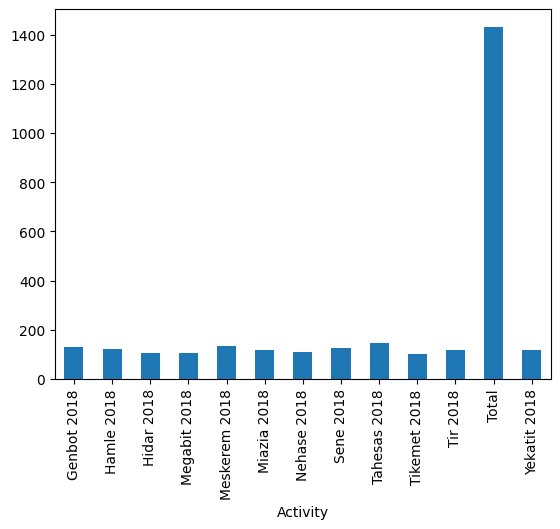

In [56]:
# Remove commas and convert the column to numeric before plotting
df['Clients receiving HIV test results (at VCT)'] = pd.to_numeric(df['Clients receiving HIV test results (at VCT)'].astype(str).str.replace(',', ''), errors='coerce')

# Group and plot
df.groupby('Activity')['Clients receiving HIV test results (at VCT)'].sum().plot(kind='bar')
plt.show()